In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np
import re

def analyze_query_frequency(csv_path_1, csv_path_2, query_column='query', min_frequency=3):
    """
    Loads two CSV files, concatenates them, performs column correction 
    (misalignment fix), removes duplicates, and finds low-frequency queries.

    This modified version also includes queries from the standard TPC-DS (131)
    and TPC-H (37) benchmarks that are NOT found in the data (i.e., have a count of 0).
    
    Args:
        csv_path_1 (str): Path to the first CSV file.
        csv_path_2 (str): Path to the second CSV file.
        query_column (str): The name of the column to analyze frequency for.
        min_frequency (int): The minimum required count (exclusive) for a query 
                             to be considered high-frequency.
                            
    Returns:
        tuple: A tuple containing:
               - list: A list of unique query strings that appear less than 
                       min_frequency times (including queries with a count of 0).
               - pandas.DataFrame: The concatenated and deduplicated DataFrame.
    """
    try:
        # Load the two dataframes
        df1 = pd.read_csv(csv_path_1)
        df2 = pd.read_csv(csv_path_2)

        # 1. Concatenate them vertically
        combined_df = pd.concat([df1, df2], ignore_index=True)
        print(f"Total rows after concatenation: {len(combined_df)}")

        # --- COLUMN MISALIGNMENT FIX (ROW-BY-ROW APPROACH) ---
        
        print("Applying row-by-row column alignment correction...")
        
        # Create lists to store corrected values
        queries = []
        datasets = []
        runtimes = []

        # Iterate through each row
        for idx, row in combined_df.iterrows():
            found = False
            row_values = row.tolist()
            
            # Go through each value in the row to find the pattern number.sql or querynumber.sql
            for i, val in enumerate(row_values):
                if pd.notna(val) and isinstance(val, str) and re.match(r'(\d+\.sql|query\d+\.sql)', val):
                    # Found the query column, take this and the next 2 values
                    queries.append(val)
                    datasets.append(row_values[i + 1] if i + 1 < len(row_values) else None)
                    runtimes.append(row_values[i + 2] if i + 2 < len(row_values) else None)
                    found = True
                    break
            
            if not found:
                # If pattern not found, append None
                queries.append(None)
                datasets.append(None)
                runtimes.append(None)

        # Create new dataframe with only the corrected columns
        combined_df = pd.DataFrame({
            query_column: queries,
            'dataset': datasets,
            'runtime': runtimes
        })
        
        print(f"Column alignment correction complete.")
        
        # --- END OF COLUMN MISALIGNMENT FIX ---

        # 2. Remove duplicate rows
        deduped_df = combined_df.drop_duplicates()
        print(f"Total rows after removing duplicates: {len(deduped_df)}")

        # 3. Count unique values in the 'query' column for queries *found* in the data
        frequency_counts = deduped_df[query_column].value_counts()
        
        # --- MODIFICATION: Include zero-count queries ---
        
        # 4. Define the complete set of all expected queries
        # TPC-DS has 131 queries (e.g., query1.sql ... query131.sql)
        tpcds_queries = {f"query{i}.sql" for i in range(1, 132)}
        # TPC-H has 37 queries (e.g., 1.sql ... 37.sql)
        tpch_queries = {f"{i}.sql" for i in range(1, 38)}
        all_expected_queries = tpcds_queries.union(tpch_queries)
        
        # 5. Re-index the counts Series to include all expected queries.
        # Queries not found in the original data will be added with a value of NaN.
        all_queries_series = frequency_counts.reindex(list(all_expected_queries))
        
        # 6. Fill NaN values with 0 (representing zero occurrences) and ensure type is int
        all_queries_series = all_queries_series.fillna(0).astype(int)

        # --- END OF MODIFICATION ---

        # 7. Find queries with a count less than the minimum frequency (now includes 0s)
        low_frequency_series = all_queries_series[all_queries_series < min_frequency]
        
        # 8. Convert the index (the query names) to a list
        low_frequency_list = low_frequency_series.index.tolist()
        
        print(f"Found {len(low_frequency_list)} queries with frequency < {min_frequency}")
        
        # Return both the list and the updated DataFrame
        return low_frequency_list, deduped_df

    except FileNotFoundError:
        print("Error: One or both CSV files were not found.")
        return [], pd.DataFrame() 
    except KeyError as ke:
        print(f"Error: Required column not found in the combined data: {ke}")
        return [], pd.DataFrame()
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return [], pd.DataFrame()

In [3]:
queries, df = analyze_query_frequency('tpcds_results/tpcds_vanilla_1027.csv', 'tpcds_results/spark_internal_listener_vanilla_results.csv', query_column='query', min_frequency=3)

Total rows after concatenation: 1176
Applying row-by-row column alignment correction...
Column alignment correction complete.
Total rows after removing duplicates: 543
Found 51 queries with frequency < 3


In [8]:
df['variant'] = "vanilla"

In [12]:
queries, df_bare = analyze_query_frequency('tpcds_results/tpcds_bare_11_03.csv', 'tpcds_results/spark_internal_listener_bare_results.csv', query_column='query', min_frequency=3)


Total rows after concatenation: 868
Applying row-by-row column alignment correction...
Column alignment correction complete.
Total rows after removing duplicates: 377
Found 96 queries with frequency < 3


In [13]:
df_bare['variant'] = "bare"

In [14]:
queries, df_cols = analyze_query_frequency('tpcds_results/cols_tpcds.csv', 'tpcds_results/spark_internal_listener_cols_results.csv', query_column='query', min_frequency=3)


Total rows after concatenation: 763
Applying row-by-row column alignment correction...
Column alignment correction complete.
Total rows after removing duplicates: 382
Found 48 queries with frequency < 3


In [15]:
df_cols['variant'] = "cols"

In [16]:
queries, df_nowrite = analyze_query_frequency('tpcds_results/nowrite_tpcds.csv', 'tpcds_results/spark_internal_listener_nowrite_results.csv', query_column='query', min_frequency=3)


Total rows after concatenation: 732
Applying row-by-row column alignment correction...
Column alignment correction complete.
Total rows after removing duplicates: 366
Found 47 queries with frequency < 3


In [17]:
df_nowrite['variant'] = "nowrite"

In [18]:
queries, df_register = analyze_query_frequency('tpcds_results/register_tpcds.csv', 'tpcds_results/spark_internal_listener_register_results.csv', query_column='query', min_frequency=3)


Total rows after concatenation: 734
Applying row-by-row column alignment correction...
Column alignment correction complete.
Total rows after removing duplicates: 368
Found 48 queries with frequency < 3


In [19]:
df_register['variant'] = "register"

In [20]:
queries, df_rowgroup = analyze_query_frequency('tpcds_results/rowgroup_tpcds.csv', 'tpcds_results/spark_internal_listener_rowgroup_results.csv', query_column='query', min_frequency=3)


Total rows after concatenation: 938
Applying row-by-row column alignment correction...
Column alignment correction complete.
Total rows after removing duplicates: 384
Found 47 queries with frequency < 3


In [21]:
df_rowgroup['variant'] = "rowgroup"

In [33]:
combined = pd.concat([df, df_bare, df_cols,df_nowrite,df_register,df_rowgroup], ignore_index=True).copy()


In [34]:
combined = combined[combined['runtime']!= -1]

In [35]:
#Then convert runtime to numeric
combined['runtime'] = pd.to_numeric(combined['runtime'], errors='coerce')

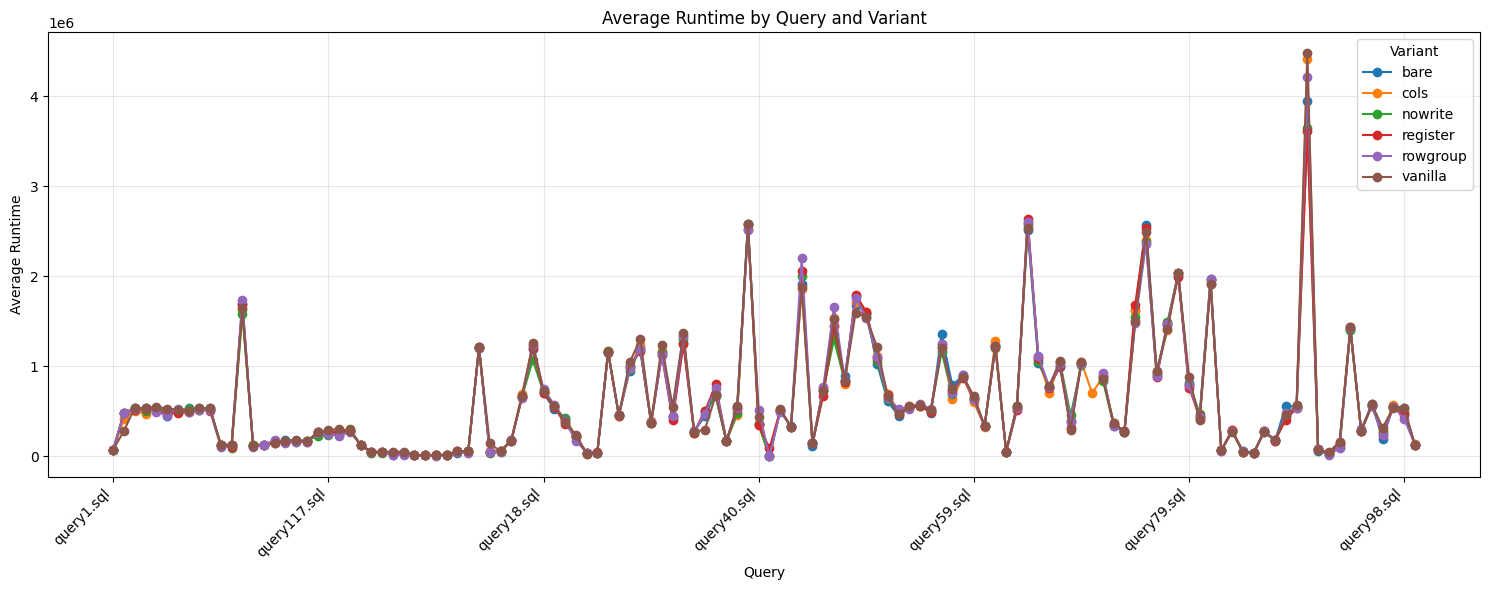

In [65]:
import matplotlib.pyplot as plt

# Create pivot table with queries as rows and variants as columns
pivot = combined.pivot_table(values='runtime', 
                              index='query', 
                              columns='variant', 
                              aggfunc='mean')
pivot.plot(kind='line', figsize=(15, 6), marker='o')
plt.xlabel('Query')
plt.ylabel('Average Runtime')
plt.title('Average Runtime by Query and Variant')
plt.legend(title='Variant')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
query_name = "query16.sql"
query_data = combined[combined['query'] == query_name]

# Get average runtime per variant for this query
avg_per_variant = query_data.groupby('variant')['runtime'].mean()
avg_per_variant_df = query_data.groupby('variant')['runtime'].mean().reset_index()
avg_per_variant_df.columns = ['variant', 'avg_runtime']
print(avg_per_variant_df.sort_values('avg_runtime'))

    variant    avg_runtime
4  rowgroup  653726.000000
0      bare  658934.000000
2   nowrite  664637.666667
5   vanilla  668838.500000
3  register  670769.333333
1      cols  698003.000000


In [64]:
combined.to_csv('tpcds_results/combined_tpcds.csv')

In [3]:
combinded = pd.read_csv('tpcds_results/combined_tpcds.csv')

In [4]:
combinded

,Unnamed: 0,query,dataset,runtime,variant
0,0,query64.sql,tpcds,3007837.0,vanilla
1,1,query85.sql,tpcds,267817.0,vanilla
2,2,query17.sql,tpcds,1257185.0,vanilla
3,3,query131.sql,tpcds,57540.0,vanilla
4,4,query112.sql,tpcds,147400.0,vanilla
...,...,...,...,...,...
2297,2415,query95.sql,tpcds,565977.0,rowgroup
2298,2416,query45.sql,tpcds,147549.0,rowgroup
2299,2417,query90.sql,tpcds,63838.0,rowgroup
2300,2418,query51.sql,tpcds,650481.0,rowgroup


In [5]:
combinded['configuration'] = "single_node"

In [6]:
combinded

,Unnamed: 0,query,dataset,runtime,variant,configuration
0,0,query64.sql,tpcds,3007837.0,vanilla,single_node
1,1,query85.sql,tpcds,267817.0,vanilla,single_node
2,2,query17.sql,tpcds,1257185.0,vanilla,single_node
3,3,query131.sql,tpcds,57540.0,vanilla,single_node
4,4,query112.sql,tpcds,147400.0,vanilla,single_node
...,...,...,...,...,...,...
2297,2415,query95.sql,tpcds,565977.0,rowgroup,single_node
2298,2416,query45.sql,tpcds,147549.0,rowgroup,single_node
2299,2417,query90.sql,tpcds,63838.0,rowgroup,single_node
2300,2418,query51.sql,tpcds,650481.0,rowgroup,single_node


In [10]:
queries, tpch_v = analyze_query_frequency('tpch_results/vanilla_tpch.csv', 'tpch_results/vanilla_tpch.csv', query_column='query', min_frequency=3)

Total rows after concatenation: 224
Applying row-by-row column alignment correction...
Column alignment correction complete.
Total rows after removing duplicates: 109
Found 132 queries with frequency < 3


In [11]:
queries, tpch_b = analyze_query_frequency('tpch_results/bare_tpch.csv', 'tpch_results/bare_tpch.csv', query_column='query', min_frequency=3)

Total rows after concatenation: 1070
Applying row-by-row column alignment correction...
Column alignment correction complete.
Total rows after removing duplicates: 137
Found 136 queries with frequency < 3


,query,dataset,runtime
0,30.sql,tpch,3871697.0
1,30.sql,tpch,3129154.0
2,23.sql,tpch,385971.0
3,37.sql,tpch,1446720.0
4,32.sql,tpch,421930.0
...,...,...,...
106,8.sql,tpch,11451878
107,4.sql,tpch,1972480
108,35.sql,tpch,1428396
109,24.sql,tpch,398337


In [12]:
## FInal analysis - tpcds

In [15]:
def process_benchmark_data(file_path, variant_name):
    """
    Processes a benchmark CSV by removing duplicates, filtering out 
    invalid runtimes, and adding a variant identifier.
    """
    try:
        # Load the dataset
        df = pd.read_csv(file_path)
        
        # 1. Drop duplicate rows
        df = df.drop_duplicates()
        
        # 2. Drop rows where runtime is -1
        # We use a boolean mask to keep only rows where runtime != -1
        df = df[df['runtime'] != -1]
        
        # 3. Create 'variant' column and assign the argument value
        df['variant'] = variant_name
        
        return df

    except FileNotFoundError:
        return "Error: The file path provided does not exist."
    except KeyError:
        return "Error: The CSV must contain 'query', 'dataset', and 'runtime' columns."

In [16]:
tpcds_v = process_benchmark_data('tpcds_results/final_results_single_node/spark_internal_listener_vanilla_results.csv', 'vanilla')

In [18]:
tpcds_b = process_benchmark_data('tpcds_results/final_results_single_node/spark_internal_listener_bare_results.csv', 'bare')

In [19]:
tpcds_r = process_benchmark_data('tpcds_results/final_results_single_node/spark_internal_listener_register_results.csv', 'register')

In [20]:
tpcds_n = process_benchmark_data('tpcds_results/final_results_single_node/spark_internal_listener_nowrite_results.csv', 'nowrite')

In [21]:
tpcds_c = process_benchmark_data('tpcds_results/final_results_single_node/spark_internal_listener_cols_results.csv', 'cols')

In [22]:
tpcds_rg = process_benchmark_data('tpcds_results/final_results_single_node/spark_internal_listener_rowgroup_results.csv', 'rowgroup')

In [28]:
combined = pd.concat([tpcds_v,tpcds_b,tpcds_r,tpcds_n,tpcds_c,tpcds_rg], ignore_index=True).copy()

In [34]:
tpch_v = process_benchmark_data('tpch_results/final_results_single_node/vanilla_tpch.csv', 'vanilla')
tpch_b = process_benchmark_data('tpch_results/final_results_single_node/bare_tpch.csv', 'bare')
tpch_r = process_benchmark_data('tpch_results/final_results_single_node/register_tpch.csv', 'register')
tpch_n = process_benchmark_data('tpch_results/final_results_single_node/nowrite_tpch.csv', 'nowrite')
tpch_c = process_benchmark_data('tpch_results/final_results_single_node/cols_tpch.csv', 'cols')
tpch_rg = process_benchmark_data('tpch_results/final_results_single_node/rowgroup_tpch.csv', 'rowgroup')
combined_tpch = pd.concat([tpch_v,tpch_b,tpch_r,tpch_n,tpch_c,tpch_rg], ignore_index=True).copy()

In [35]:
single_node_modified_spark = pd.concat([combined,combined_tpch], ignore_index=True).copy()

In [36]:
single_node_modified_spark

,query,dataset,runtime,variant
0,query19.sql,tpcds,552919,vanilla
1,query81.sql,tpcds,68846,vanilla
2,query48.sql,tpcds,859841,vanilla
3,query77.sql,tpcds,1414224,vanilla
4,query13.sql,tpcds,1216296,vanilla
...,...,...,...,...
2573,3.sql,tpch,3803850,rowgroup
2574,8.sql,tpch,14728800,rowgroup
2575,20.sql,tpch,2467707,rowgroup
2576,18.sql,tpch,12728742,rowgroup


In [38]:
single_node_modified_spark.to_csv('combined_results_single_node.csv')

In [39]:
## unmod spark

In [40]:
tpcds_v_u = process_benchmark_data('tpcds_results/unmod_spark/spark_internal_listener_vanilla_results.csv', 'vanilla')
tpcds_b_u = process_benchmark_data('tpcds_results/unmod_spark/spark_internal_listener_bare_results.csv', 'bare')
tpcds_r_u = process_benchmark_data('tpcds_results/unmod_spark/spark_internal_listener_register_results.csv', 'register')
tpcds_n_u = process_benchmark_data('tpcds_results/unmod_spark/spark_internal_listener_nowrite_results.csv', 'nowrite')
tpcds_c_u = process_benchmark_data('tpcds_results/unmod_spark/spark_internal_listener_cols_results.csv', 'cols')

In [41]:
combined_tpcds_u = pd.concat([tpcds_v_u,tpcds_b_u,tpcds_r_u,tpcds_n_u,tpcds_c_u], ignore_index=True).copy()

In [42]:
combined_tpcds_u

,query,dataset,runtime,variant
0,query17.sql,tpcds,1201264,vanilla
1,query20.sql,tpcds,199498,vanilla
2,query22.sql,tpcds,43534,vanilla
3,query11.sql,tpcds,1426306,vanilla
4,query5.sql,tpcds,1508205,vanilla
...,...,...,...,...
2341,query51.sql,tpcds,630695,cols
2342,query41.sql,tpcds,3037,cols
2343,query51.sql,tpcds,698946,cols
2344,query51.sql,tpcds,701253,cols


In [43]:
tpch_v_u = process_benchmark_data('tpch_results/unmod_spark/spark_internal_listener_vanilla_results.csv', 'vanilla')
tpch_b_u = process_benchmark_data('tpch_results/unmod_spark/spark_internal_listener_bare_results.csv', 'bare')
tpch_r_u = process_benchmark_data('tpch_results/unmod_spark/spark_internal_listener_register_results.csv', 'register')
tpch_n_u = process_benchmark_data('tpch_results/unmod_spark/spark_internal_listener_nowrite_results.csv', 'nowrite')
tpch_c_u = process_benchmark_data('tpch_results/unmod_spark/spark_internal_listener_cols_results.csv', 'cols')

In [44]:
combined_tpch_u = pd.concat([tpch_v_u,tpch_b_u,tpch_r_u,tpch_n_u,tpch_c_u], ignore_index=True).copy()

In [45]:
combined_u = pd.concat([combined_tpch_u,combined_tpcds_u], ignore_index=True).copy()

In [47]:
combined_u['configuration'] = "single_node_unmod_spark"

In [48]:
single_node_modified_spark['configuration'] = "single_node_mod_spark"

In [49]:
all_results = pd.concat([combined_u,single_node_modified_spark], ignore_index=True).copy()

In [50]:
all_results

,query,dataset,runtime,variant,configuration
0,6.sql,tpch,1100820,vanilla,unmod_spark
1,2.sql,tpch,975728,vanilla,unmod_spark
2,1.sql,tpch,1267089,vanilla,unmod_spark
3,5.sql,tpch,9637936,vanilla,unmod_spark
4,3.sql,tpch,3538577,vanilla,unmod_spark
...,...,...,...,...,...
5454,3.sql,tpch,3803850,rowgroup,single_node_mod_spark
5455,8.sql,tpch,14728800,rowgroup,single_node_mod_spark
5456,20.sql,tpch,2467707,rowgroup,single_node_mod_spark
5457,18.sql,tpch,12728742,rowgroup,single_node_mod_spark


In [51]:
all_results.to_csv('all_results.csv')

In [3]:
all_results = pd.read_csv('all_results.csv')

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

def save_benchmark_charts(df, output_folder="benchmark_plots"):
    # Create the directory if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        print(f"Created folder: {output_folder}")

    variant_order = ["vanilla", "bare", "register", "nowrite", "cols", "rowgroup"]
    configs = df['configuration'].unique()
    datasets = df['dataset'].unique()

    for config in configs:
        for dataset in datasets:
            subset_all = df[(df['configuration'] == config) & (df['dataset'] == dataset)]
            if subset_all.empty: continue

            queries = sorted(subset_all['query'].unique())
            num_splits = 3 if "tpcds" in dataset.lower() else 1
            query_chunks = np.array_split(queries, num_splits)
            
            for i, chunk in enumerate(query_chunks):
                subset = subset_all[subset_all['query'].isin(chunk)]
                
                plt.figure(figsize=(22, 10)) # Slightly larger for high-quality saving
                sns.barplot(
                    data=subset, 
                    x='query', 
                    y='runtime', 
                    hue='variant', 
                    hue_order=[v for v in variant_order if v in subset['variant'].unique()]
                )

                title_suffix = f" (Part {i+1} of {num_splits})" if num_splits > 1 else ""
                plt.title(f"Performance: {config} | {dataset}{title_suffix}", fontsize=18)
                plt.xticks(rotation=90, fontsize=10)
                plt.tight_layout()

                # Generate a clean filename
                # Example: single_node_mod_spark_tpcds_part1.png
                file_name = f"{config}_{dataset}_part{i+1}.png".replace(" ", "_")
                save_path = os.path.join(output_folder, file_name)
                
                # Save with high DPI for clarity (good for reports/presentations)
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                plt.close() # Close the figure to free up memory
                
                print(f"Saved: {save_path}")

# Run the function
save_benchmark_charts(all_results)

Saved: benchmark_plots/unmod_spark_tpch_part1.png
Saved: benchmark_plots/unmod_spark_tpcds_part1.png
Saved: benchmark_plots/unmod_spark_tpcds_part2.png
Saved: benchmark_plots/unmod_spark_tpcds_part3.png
Saved: benchmark_plots/single_node_mod_spark_tpch_part1.png
Saved: benchmark_plots/single_node_mod_spark_tpcds_part1.png
Saved: benchmark_plots/single_node_mod_spark_tpcds_part2.png
Saved: benchmark_plots/single_node_mod_spark_tpcds_part3.png


In [8]:
import pandas as pd

def calculate_refined_overhead_stats(df):
    """
    1. Averages runtimes per query/variant (to handle iterations).
    2. Calculates overhead per query relative to vanilla.
    3. Summarizes overheads (min, median, max, mean) per config/dataset.
    """
    
    # Step 1: Calculate the average runtime for each unique query-variant combination
    # This ensures that if query1 was run 3 times, we use its mean for comparison.
    avg_per_query = df.groupby(['configuration', 'dataset', 'query', 'variant'])['runtime'].mean().reset_index()

    # Step 2: Pivot the data so variants are columns
    # Rows are now unique (configuration, dataset, query)
    pivot_df = avg_per_query.pivot_table(
        index=['configuration', 'dataset', 'query'], 
        columns='variant', 
        values='runtime'
    ).reset_index()

    # Step 3: Define comparisons and calculate overhead ratios
    # Ratio = (Avg Runtime of Variant) / (Avg Runtime of Vanilla)
    comparisons = {
        'register_vs_vanilla': 'register',
        'column_vs_vanilla': 'cols',
        'rowgroup_vs_vanilla': 'rowgroup'
    }

    overhead_cols = []
    if 'vanilla' in pivot_df.columns:
        for label, col_name in comparisons.items():
            if col_name in pivot_df.columns:
                pivot_df[label] = pivot_df[col_name] / pivot_df['vanilla']
                overhead_cols.append(label)
    else:
        return "Error: 'vanilla' column missing from data."

    # Step 4: Aggregate the overhead ratios to get the final stats
    # We group by config and dataset to see the spread of performance across all queries
    stats = pivot_df.groupby(['configuration', 'dataset'])[overhead_cols].agg(['min', 'median', 'max', 'mean'])
    
    # Optional: Clean up multi-index column names for easier reading
    stats.columns = ['_'.join(col).strip() for col in stats.columns.values]
    
    return stats



In [9]:
final_stats = calculate_refined_overhead_stats(all_results)
print(final_stats)

                               register_vs_vanilla_min  \
configuration         dataset                            
single_node_mod_spark tpcds                   0.692268   
                      tpch                    0.675381   
unmod_spark           tpcds                   0.526693   
                      tpch                    0.749739   

                               register_vs_vanilla_median  \
configuration         dataset                               
single_node_mod_spark tpcds                      0.979950   
                      tpch                       0.994747   
unmod_spark           tpcds                      0.995613   
                      tpch                       0.992339   

                               register_vs_vanilla_max  \
configuration         dataset                            
single_node_mod_spark tpcds                   1.122926   
                      tpch                    1.396726   
unmod_spark           tpcds                   1.2194

In [12]:
import pandas as pd

def calculate_detailed_overhead_stats(df):
    """
    Calculates the distribution (min, median, mean, max) of overheads 
    across all queries for each configuration and dataset.
    """
    # 1. Average runtimes per query/variant to handle multiple iterations
    # This ensures we have one 'baseline' and one 'comparison' value per query
    avg_df = df.groupby(['configuration', 'dataset', 'query', 'variant'])['runtime'].mean().reset_index()

    # 2. Pivot to get variants into columns so we can compare them side-by-side
    pivot_df = avg_df.pivot_table(
        index=['configuration', 'dataset', 'query'], 
        columns='variant', 
        values='runtime'
    ).reset_index()

    # 3. Calculate the overhead ratio for each query
    # Ratio = Variant / Vanilla (e.g., 1.05 means 5% overhead)
    comparisons = {
        'register': 'register_overhead',
        'cols': 'column_overhead',
        'rowgroup': 'rowgroup_overhead'
    }

    overhead_cols = []
    if 'vanilla' in pivot_df.columns:
        for var_name, overhead_label in comparisons.items():
            if var_name in pivot_df.columns:
                pivot_df[overhead_label] = pivot_df[var_name] / pivot_df['vanilla']
                overhead_cols.append(overhead_label)
    else:
        raise ValueError("Dataframe must contain 'vanilla' variant as a baseline.")

    # 4. Group by config/dataset and calculate the distribution of the overheads
    # This gives us the min, median, mean, and max overhead seen across the query set
    stats_summary = pivot_df.groupby(['configuration', 'dataset'])[overhead_cols].agg(
        ['min', 'median', 'mean', 'max']
    )

    # Flatten the multi-index columns for easier reading (e.g., 'column_overhead_max')
    stats_summary.columns = ['_'.join(col).strip() for col in stats_summary.columns.values]
    
    return stats_summary



In [13]:
stats_results = calculate_detailed_overhead_stats(all_results)
print(stats_results.to_string())

                               register_overhead_min  register_overhead_median  register_overhead_mean  register_overhead_max  column_overhead_min  column_overhead_median  column_overhead_mean  column_overhead_max  rowgroup_overhead_min  rowgroup_overhead_median  rowgroup_overhead_mean  rowgroup_overhead_max
configuration         dataset                                                                                                                                                                                                                                                                                        
single_node_mod_spark tpcds                 0.692268                  0.979950                0.967944               1.122926             0.701866                0.997506              0.981154             1.121989               0.227355                  0.982463                0.972857               1.186938
                      tpch                  0.675381                  

In [15]:
stats_results.to_csv('summary_results.csv')